In [1]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 15


In [2]:
with open("all_group_errors.pkl", "rb") as f:
    all_group_errors = pickle.load(f)
all_group_errors

[{487: {487: 0.16839086078107357,
   436: 0.11862756410413537,
   469: 0.1870788443265549,
   459: 0.32693500059549924,
   463: 0.34998183329532173,
   484: 0.18837073686259304,
   448: 0.18287392389029264,
   446: 0.29264368232889254,
   500: 0.26384142599999905,
   489: 0.29225954887541855,
   473: 0.48348691004973193},
  436: {487: 0.17440970919709256,
   436: 0.10878647866943651,
   469: 0.1853718301363897,
   459: 0.38264208714492987,
   463: 0.38136350276109615,
   484: 0.16166420216065142,
   448: 0.1950367832556367,
   446: 0.36463177845370576,
   500: 0.37454887852072716,
   489: 0.3600877404890277,
   473: 0.4581249718482678},
  469: {487: 0.17702198995554702,
   436: 0.12164263272550234,
   469: 0.181686805620631,
   459: 0.3085692412540561,
   463: 0.33667705626583394,
   484: 0.19007261605256826,
   448: 0.190353552225445,
   446: 0.2707022355228174,
   500: 0.24291102774441242,
   489: 0.2697248381816528,
   473: 0.48155582065765673},
  459: {487: 0.357348154873607,
   43

In [4]:
data_groups = []
for idx, each_car_errors in enumerate(all_group_errors):
    confusion_matrix = np.zeros((len(each_car_errors), len(each_car_errors)))
    for i, car_id in enumerate(each_car_errors.keys()):
        for j, car_data_id in enumerate(each_car_errors.keys()):
            confusion_matrix[i, j] = each_car_errors[car_id][car_data_id]
    for i in range(len(each_car_errors)):
        for j in range(len(each_car_errors)):
            if confusion_matrix[i, j] < confusion_matrix[i, i]:
                confusion_matrix[i, j] = 0.0
    for i in range(len(each_car_errors)):
        confusion_matrix[i, :] = confusion_matrix[i, :] - confusion_matrix[i, i]
    confusion_matrix[confusion_matrix < 0] = 0.0

    # For each row_i and col_i, find sum of that row and column as the error score of that car
    car_error_scores = {}
    for i, car_id in enumerate(each_car_errors.keys()):
        row_sum = np.sum(confusion_matrix[i, :]) / len(each_car_errors)
        col_sum = np.sum(confusion_matrix[:, i]) / len(each_car_errors)

        car_error_scores[car_id] = row_sum + 2 * col_sum
    data_groups.append({"name": f"Group {idx+1}", "data": car_error_scores})

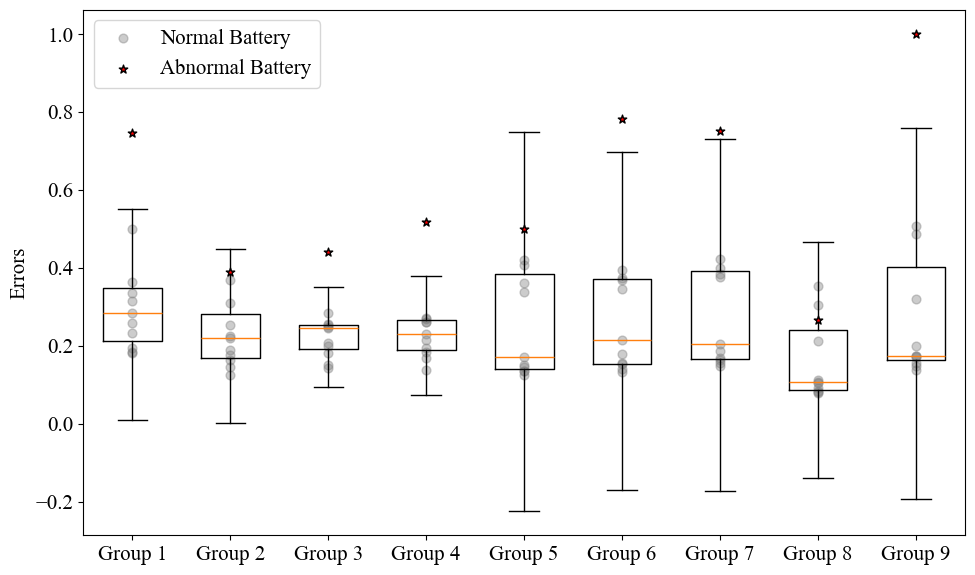

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

# Formatting for the internal labels
text_style = dict(va='center', ha='center', fontweight='bold', fontsize=9,
                  bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))

# Loop through each group to plot
for i, group in enumerate(data_groups):
    pos = i + 1  # X-position for the boxplot
    vals = list(group["data"].values())
    
    # Identify normal vs abnormal (last point)
    normal_vals = vals[:-1]
    abnormal_val = vals[-1]
    
    # Calculate Stats
    q1, med, q3 = np.percentile(vals, [25, 50, 75])
    iqr = q3 - q1
    whislo, whishi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    
    # 1. Plot the Boxplot at position 'pos'
    stats = [{'label': group["name"], 'q1': q1, 'med': med, 'q3': q3, 
              'whislo': whislo, 'whishi': whishi, 'fliers': []}]
    ax.bxp(stats, positions=[pos], showfliers=False, widths=0.6)
    
    # # 2. Add Internal Labels (Q1, Med, Q3)
    # ax.text(pos, q3, f'Q3:{q3:.2f}', color='darkred', **text_style)
    # ax.text(pos, med, f'M:{med:.2f}', color='green', **text_style)
    # ax.text(pos, q1, f'Q1:{q1:.2f}', color='blue', **text_style)
    
    # # 3. Add Whisker Labels
    # ax.text(pos, whishi + 0.02, f'Max:{whishi:.2f}', color='black', ha='center', fontsize=8)
    # ax.text(pos, whislo - 0.02, f'Min:{whislo:.2f}', color='black', ha='center', va='top', fontsize=8)
    
    # 4. Plot Scatter Points
    # x_jitter = np.random.normal(pos, 0.04, size=len(normal_vals))
    x_jitter = [pos] * len(normal_vals)
    ax.scatter(x_jitter, normal_vals, color='gray', alpha=0.4, s=40, label='Normal Battery' if i==0 else "")
    
    # Plot Abnormal Point
    ax.scatter([pos], [abnormal_val if i==0 else abnormal_val], color='red', marker='*',
               s=40, edgecolors='black', zorder=5, label='Abnormal Battery' if i==0 else "")

# Final Formatting
ax.set_ylabel('Errors')
# ax.set_title('Multi-Group Comparison with Custom Labels')
ax.set_xticks(range(1, len(data_groups) + 1))
ax.set_xticklabels([g["name"] for g in data_groups])
ax.legend()

plt.tight_layout()
plt.savefig("iqr_error_plot.png", dpi=300)
plt.show()

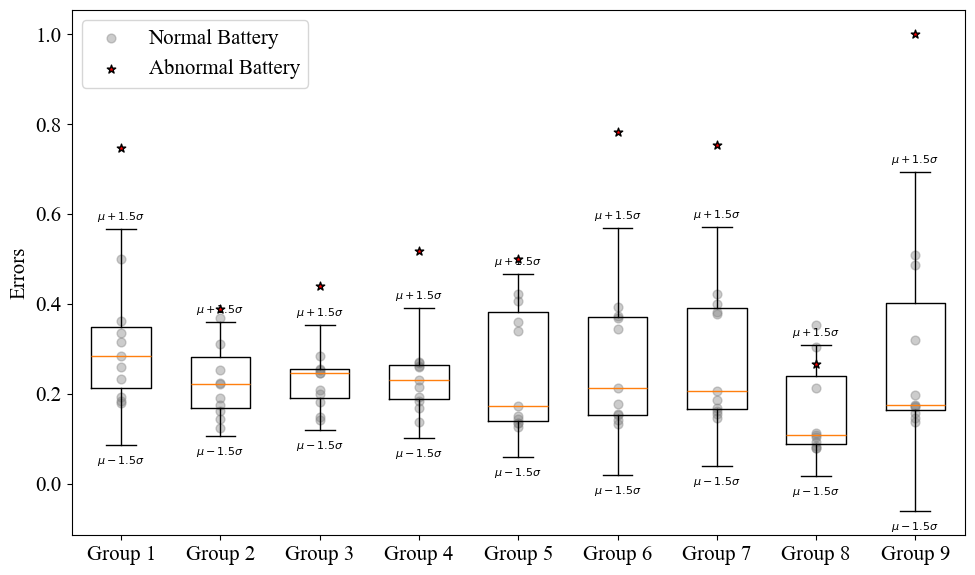

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

# Formatting for the internal labels
text_style = dict(va='center', ha='center', fontweight='bold', fontsize=9,
                  bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))

# Loop through each group to plot
for i, group in enumerate(data_groups):
    pos = i + 1  # X-position for the boxplot
    vals = list(group["data"].values())
    mean_val = float(np.mean(vals))
    std_val = float(np.std(vals))
    
    # Identify normal vs abnormal (last point)
    normal_vals = vals[:-1]
    abnormal_val = vals[-1]
    
    # Calculate Stats
    q1, med, q3 = np.percentile(vals, [25, 50, 75])
    whislo, whishi = mean_val - 1.5 * std_val, mean_val + 1.5 * std_val
    
    # 1. Plot the Boxplot at position 'pos'
    stats = [{'label': group["name"], 'q1': q1, 'med': med, 'q3': q3, 
              'whislo': whislo, 'whishi': whishi, 'fliers': []}]
    ax.bxp(stats, positions=[pos], showfliers=False, widths=0.6)
    
    # # 2. Add Internal Labels (Q1, Med, Q3)
    # ax.text(pos, q3, f'Q3:{q3:.2f}', color='darkred', **text_style)
    # ax.text(pos, med, f'M:{med:.2f}', color='green', **text_style)
    # ax.text(pos, q1, f'Q1:{q1:.2f}', color='blue', **text_style)
    
    # 3. Add Whisker Labels
    ax.text(pos, whishi + 0.02, f'$\mu+1.5\sigma$', color='black', ha='center', fontsize=8)
    ax.text(pos, whislo - 0.02, f'$\mu-1.5\sigma$', color='black', ha='center', va='top', fontsize=8)
    
    # 4. Plot Scatter Points
    # x_jitter = np.random.normal(pos, 0.04, size=len(normal_vals))
    x_jitter = [pos] * len(normal_vals)
    ax.scatter(x_jitter, normal_vals, color='gray', alpha=0.4, s=40, label='Normal Battery' if i==0 else "")
    
    # Plot Abnormal Point
    ax.scatter([pos], [abnormal_val if i==0 else abnormal_val], color='red', marker='*',
               s=40, edgecolors='black', zorder=5, label='Abnormal Battery' if i==0 else "")

# Final Formatting
ax.set_ylabel('Errors')
# ax.set_title('Multi-Group Comparison with Custom Labels')
ax.set_xticks(range(1, len(data_groups) + 1))
ax.set_xticklabels([g["name"] for g in data_groups])
ax.legend()

plt.tight_layout()
plt.savefig("mean_std_error_plot.png", dpi=300)
plt.show()

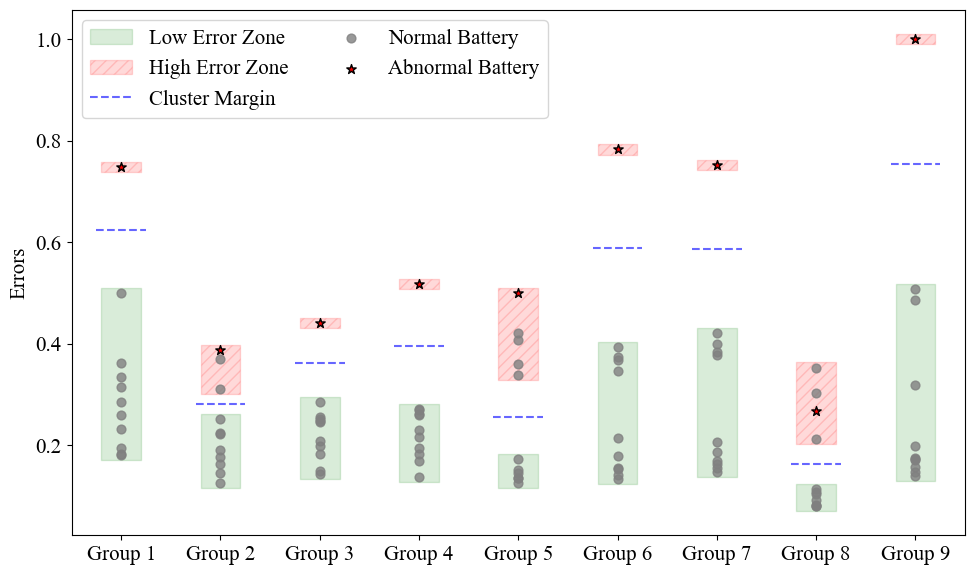

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming data_groups is your list of dicts
# data_groups = [...]

fig, ax = plt.subplots(figsize=(10, 6))

# Define the vertical padding for the boxes
padding = 0.01 

for i, group in enumerate(data_groups):
    # 1. Sort by value to find the gap
    sorted_items = sorted(group["data"].items(), key=lambda x: x[1])
    values = np.array([item[1] for item in sorted_items])

    # 2. Find the gap and split the groups
    gaps = np.diff(values)
    max_gap_index = np.argmax(gaps)
    avg_other_gaps = np.mean(gaps)

    pos = i + 1
    
    if gaps[max_gap_index] > (avg_other_gaps * 2):
        # Define the sub-sets
        group_lower_vals = values[:max_gap_index + 1]
        group_upper_vals = values[max_gap_index + 1:]
        
        # Horizontal width for the box and the line
        x_min, x_max = pos - 0.2, pos + 0.2
        
        # 3. GREEN RECTANGLE (Lower Group) with padding
        y_min_low = min(group_lower_vals) - padding
        y_max_low = max(group_lower_vals) + padding
        ax.fill_between([x_min, x_max], y_min_low, y_max_low, 
                        color='green', alpha=0.15, edgecolor='green', 
                        linewidth=1, label='Low Error Zone' if i==0 else "")
        
        # 4. RED RECTANGLE (Upper Group) with padding
        y_min_up = min(group_upper_vals) - padding
        y_max_up = max(group_upper_vals) + padding
        ax.fill_between([x_min, x_max], y_min_up, y_max_up, 
                        color='red', alpha=0.15, edgecolor='red', hatch='///',
                        linewidth=1, label='High Error Zone' if i==0 else "")
        
        # 5. ADD THE SPLIT LINE (Centered in the gap)
        max_gap = gaps[max_gap_index]
        lower_cluster_max = max(group_lower_vals)
        gap_mid = lower_cluster_max + (max_gap / 2)
        
        ax.hlines(y=gap_mid, xmin=x_min - 0.05, xmax=x_max + 0.05, 
                  color='blue', linestyle='--', linewidth=1.5, alpha=0.6,
                  label='Cluster Margin' if i==0 else "")

    # 6. Plot Points
    vals = list(group["data"].values())
    normal_vals = vals[:-1]
    abnormal_val = vals[-1]
    
    # Normal points
    ax.scatter([pos] * len(normal_vals), normal_vals, color='gray', alpha=0.8, s=40, 
               zorder=10, label = "Normal Battery")
    
    # Abnormal point
    ax.scatter([pos], [abnormal_val], color='red', s=50, edgecolors='black', marker='*',
               zorder=11, label='Abnormal Battery' if i==0 else "")

# Formatting
ax.set_ylabel('Errors')
ax.set_xticks(range(1, len(data_groups) + 1))
ax.set_xticklabels([g["name"] for g in data_groups])
ax.set_xlim(0.5, len(data_groups) + 0.5)

# Clean legend
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), ncol=2)

plt.tight_layout()
plt.savefig("cluster_error_zones.png", dpi=300)
plt.show()

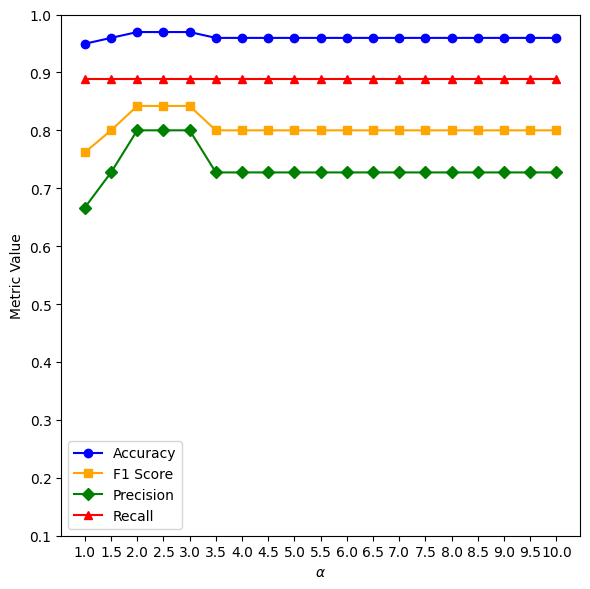

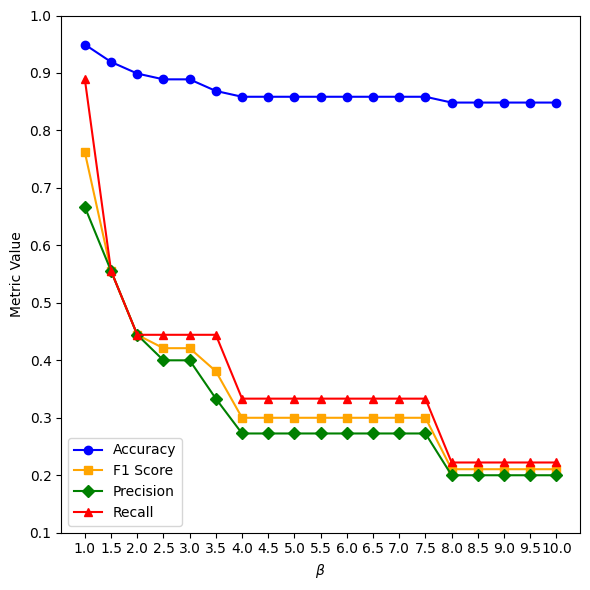

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Define metrics
metrics = ['Accuracy', 'F1', 'Precision', 'Recall']
labels = ['Accuracy', 'F1 Score', 'Precision', 'Recall']
colors = ['blue', 'orange', 'green', 'red']
markers = ['o', 's', 'D', '^']

# --- Alpha = 1 fixed ---
df = pd.read_csv("b3alpha1.csv")
x_alpha = df["Beta"]  # beta values
line_acc = df["Accuracy"]
line_f1 = df["F1"]
line_pre = df["Precision"]
line_rec = df["Recall"]
plt.figure(figsize=(6,6))
for line, label, color, marker in zip([line_acc, line_f1, line_pre, line_rec], labels, colors, markers):
    plt.plot(x_alpha, line, marker=marker, color=color, label=label)
# plt.title("Alpha = 1 fixed (1vsX)")
# plt.xlabel("Beta")
plt.xlabel("$\\alpha$") # Changed to Alpha for consistency with the paper
plt.ylabel("Metric Value")
plt.ylim(0.1, 1.0)
plt.xticks(x_alpha)
plt.legend()
plt.tight_layout()
plt.savefig("b3_abla_alpha1_fixed.png", dpi=300)
plt.show()

# --- Beta = 1 fixed ---
df = pd.read_csv("b3beta1.csv")
x_beta = df["Alpha"]  # alpha values
line_acc = df["Accuracy"]
line_f1 = df["F1"]
line_pre = df["Precision"]
line_rec = df["Recall"]

plt.figure(figsize=(6,6))
for line, label, color, marker in zip([line_acc, line_f1, line_pre, line_rec], labels, colors, markers):
    plt.plot(x_beta, line, marker=marker, color=color, label=label)

# plt.title("Beta = 1 fixed (Xvs1)")
# plt.xlabel("Alpha")
plt.xlabel("$\\beta$") # Changed to Beta for consistency with the paper
plt.ylabel("Metric Value")
plt.ylim(0.1, 1.0)
plt.xticks(x_beta)
plt.legend()
plt.tight_layout()
plt.savefig("b3_abla_beta1_fixed.png", dpi=300)
plt.show()


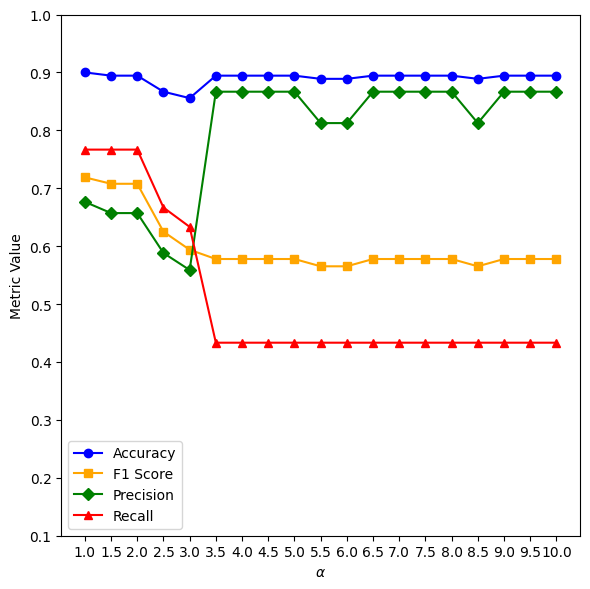

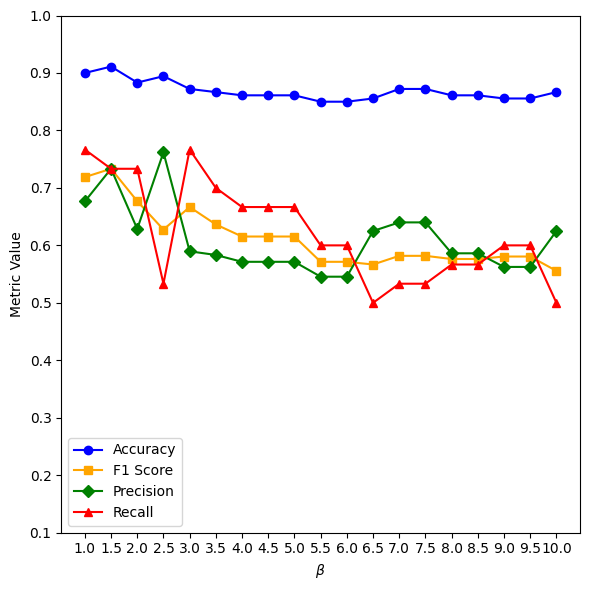

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Define metrics
metrics = ['Accuracy', 'F1', 'Precision', 'Recall']
labels = ['Accuracy', 'F1 Score', 'Precision', 'Recall']
colors = ['blue', 'orange', 'green', 'red']
markers = ['o', 's', 'D', '^']

# --- Alpha = 1 fixed ---
df = pd.read_csv("b1alpha1.csv")
x_alpha = df["Beta"]  # beta values
line_acc = df["Accuracy"]
line_f1 = df["F1"]
line_pre = df["Precision"]
line_rec = df["Recall"]
plt.figure(figsize=(6,6))
for line, label, color, marker in zip([line_acc, line_f1, line_pre, line_rec], labels, colors, markers):
    plt.plot(x_alpha, line, marker=marker, color=color, label=label)
# plt.title("Alpha = 1 fixed (1vsX)")
# plt.xlabel("Beta")
plt.xlabel("$\\alpha$") # Changed to Alpha for consistency with the paper
plt.ylabel("Metric Value")
plt.ylim(0.1, 1.0)
plt.xticks(x_alpha)
plt.legend()
plt.tight_layout()
plt.savefig("b1_abla_alpha1_fixed.png", dpi=300)
plt.show()

# --- Beta = 1 fixed ---
df = pd.read_csv("b1beta1.csv")
x_beta = df["Alpha"]  # alpha values
line_acc = df["Accuracy"]
line_f1 = df["F1"]
line_pre = df["Precision"]
line_rec = df["Recall"]

plt.figure(figsize=(6,6))
for line, label, color, marker in zip([line_acc, line_f1, line_pre, line_rec], labels, colors, markers):
    plt.plot(x_beta, line, marker=marker, color=color, label=label)

# plt.title("Beta = 1 fixed (Xvs1)")
# plt.xlabel("Alpha")
plt.xlabel("$\\beta$") # Changed to Beta for consistency with the paper
plt.ylabel("Metric Value")
plt.ylim(0.1, 1.0)
plt.xticks(x_beta)
plt.legend()
plt.tight_layout()
plt.savefig("b1_abla_beta1_fixed.png", dpi=300)
plt.show()
